#            Key Cost Driver Analysis: Shipping Cost



**Overview**

This project analyzes key factors influencing shipping costs in a dynamic supply chain environment using exploratory data analysis (EDA) and correlation techniques.

The goal is to evaluate whether commonly assumed operational variables such as fuel consumption, loading/unloading time, and congestion levels significantly impact shipping cost.


**Dataset**

Source: Kaggle – Logistics and Supply Chain Dataset

Total Records: ~32,000

Features: 26 variables including:

Fuel consumption rate

Traffic congestion level

Warehouse inventory level

Loading/unloading time

Lead time

Customs clearance time

Shipping costs


**Objective**

To identify and quantify relationships between shipping costs and operational, environmental, and logistical factors.

**Analysis Performed**

Data Extraction & Preparation

1.   Dataset loaded using pandas
2.   Selected relevant variables for cost analysis: shipping_costs:

*   shipping_costs
*   fuel_consumption_rate
*   loading_unloading_time

In [1]:
## Extract - install kaggle

!pip install kagglehub

In [ ]:
#Download Dataset from kaggle

import kagglehub

path = kagglehub.dataset_download("datasetengineer/logistics-and-supply-chain-dataset")

print("dataset path:", path)

Using Colab cache for faster access to the 'logistics-and-supply-chain-dataset' dataset.
dataset path: /kaggle/input/logistics-and-supply-chain-dataset


In [ ]:
import os

print(os.listdir(path))

['dynamic_supply_chain_logistics_dataset.csv']


In [ ]:
import pandas as pd

file_path = os.path.join(path, "dynamic_supply_chain_logistics_dataset.csv")  # change name

df = pd.read_csv(file_path)


In [ ]:
df.head(5)

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

Here analyzes key factors influencing shipping costs in a dynamic supply chain environment using exploratory data analysis and correlation techniques.

**Objective***

To identify and quantify relationships between shipping costs and operational, environmental, and logistical variables such as fuel consumption, lead time, congestion levels, and risk factors.


In [ ]:
selected_columns = [
    'shipping_costs',
    'fuel_consumption_rate',
    'traffic_congestion_level',
    'warehouse_inventory_level',
    'loading_unloading_time',
    'lead_time_days',
    'customs_clearance_time',

]


corr = df[selected_columns].corr()
print(corr['shipping_costs'].sort_values(ascending=False))

shipping_costs               1.000000
fuel_consumption_rate        0.005036
loading_unloading_time       0.003086
traffic_congestion_level    -0.000031
customs_clearance_time      -0.000841
warehouse_inventory_level   -0.005494
lead_time_days              -0.007044
Name: shipping_costs, dtype: float64


In [ ]:
cost_analysis = df[['timestamp', 'shipping_costs', 'fuel_consumption_rate']]\
    .nlargest(10, 'fuel_consumption_rate').round (2)

cost_analysis

,timestamp,shipping_costs,fuel_consumption_rate
9132,2022-01-16 12:00:00,105.47,20.0
5800,2021-08-30 16:00:00,964.05,20.0
4474,2021-07-06 10:00:00,101.13,20.0
28062,2024-03-15 06:00:00,122.54,20.0
3853,2021-06-10 13:00:00,130.45,20.0
18849,2023-02-25 09:00:00,999.99,20.0
19547,2023-03-26 11:00:00,989.56,20.0
21679,2023-06-23 07:00:00,767.48,20.0
4721,2021-07-16 17:00:00,801.81,20.0
17312,2022-12-23 08:00:00,100.52,20.0


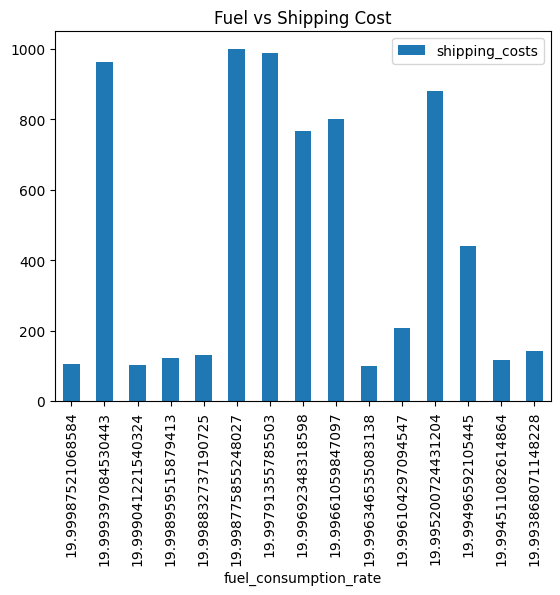

In [ ]:
import matplotlib.pyplot as plt

Cost_analysis.plot( x='fuel_consumption_rate', y='shipping_costs',kind='bar')

plt.title('Fuel vs Shipping Cost')
plt.show()


In [ ]:
cost_analysis_based_on_loading = df[['shipping_costs', 'loading_unloading_time']]\
    .nlargest(10, 'loading_unloading_time', )

cost_analysis_based_on_loading


,shipping_costs,loading_unloading_time
10406,101.800275,5.000000
15111,846.924976,5.000000
12915,354.520910,4.999991
26685,157.842239,4.999991
14742,100.380650,4.999988
845,236.783191,4.999981
13030,483.387509,4.999980
18210,440.922654,4.999977
20586,131.457342,4.999977
18386,776.372801,4.999974


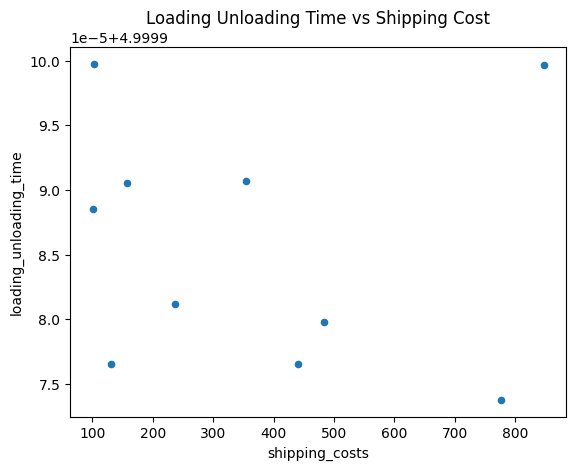

In [ ]:
cost_analysis_based_on_loading.plot (x = 'shipping_costs', y = 'loading_unloading_time', kind = 'scatter')

plt.title('Loading Unloading Time vs Shipping Cost')
plt.show()

**Conclusion**


In conclusion, the analysis demonstrates that commonly assumed operational factors like fuel consumption and loading/unloading time do not significantly explain variations in shipping costs in this dataset. This highlights the importance of using more advanced analytical approaches and incorporating additional variables to better understand cost behavior in supply chain operations.
